# Experiments v3 — Recall, Calibration, and Forecast Quality

This notebook complements `regression_score.ipynb` and `analysiscontinued.ipynb`. Those
establish the headline result: per-(model, domain) **recall fidelity** $R_{m,d}$ predicts
**Brier score**, with a within-market local-neighborhood version of the same finding at
the market level.

Here we ask the questions that those notebooks **did not address** and that change the
interpretation of the headline result:

1. **Coverage diagnostics.** Which models actually have graded recall? Which have
   forecasts? The two sets are not the same.
2. **Is the post-cutoff "Brier" really a Brier?** $(p_\text{model} - p_\text{market})^2$
   is a *market-disagreement* loss, not a Brier score. We re-examine.
3. **Calibration vs accuracy.** Brier conflates calibration and resolution. We do
   reliability curves and the Murphy decomposition.
4. **Recall state → forecast behavior.** Does recall mostly buy *confidence*, or *accuracy*,
   or both? We decompose using $|p-0.5|$ and signed direction.
5. **Confident-wrong drill.** When `recall_score=0`, are probabilities extreme?
6. **Semantic vs TF-IDF neighbors.** `analysiscontinued.ipynb` used TF-IDF for
   k-nearest. We re-run with the 768-d embeddings in `embeddings.npz`.
7. **Horizon decay.** Does post-cutoff forecast accuracy degrade with `close_time`?
8. **Inter-model agreement** as a function of difficulty.
9. **Bootstrap CIs** on the headline coefficient.
10. **Synthesis** — things that still don't sit right.

Most cells reuse helpers from `scripts.py` and `fidelity_regression.py`.

In [28]:
import sys, os, json, math, glob
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

ANALYSIS_DIR = Path(os.getcwd()).resolve()
if ANALYSIS_DIR.name != "analysis":
    ANALYSIS_DIR = ANALYSIS_DIR / "analysis"
RESEARCH_DIR = ANALYSIS_DIR.parent
sys.path.insert(0, str(ANALYSIS_DIR))

import scripts as S

DOMAINS = S.DOMAINS
PALETTE = S.PALETTE
MODEL_DISPLAY = S.MODEL_DISPLAY
SHORT_DOMAIN = S.SHORT_DOMAIN

def disp(m): return MODEL_DISPLAY.get(m, m)

print("Research dir:", RESEARCH_DIR)
print("Domains:", len(DOMAINS))

Research dir: /Users/shubhaankargupta/AIForecastPaper/Research
Domains: 9


In [29]:
# Recall + forecast loaders
recall_records = S.load_recall_records()
fc_records     = S.load_forecast_records()
panel_rows     = S.build_fidelity_matrix(recall_records)
difficulty     = S.compute_domain_difficulty()

# Wide market-level frame
fc_df     = S.build_forecast_df(recall_records, fc_records)
recall_df = pd.DataFrame(recall_records)

print(f"recall records: {len(recall_records):,}   forecast records: {len(fc_records):,}")
print(f"market-model rows in fc_df: {len(fc_df):,}")
print(f"models in recall: {sorted(recall_df['model'].unique())}")
print(f"models in forecast: {sorted({r['model'] for r in fc_records})}")

recall records: 5,200   forecast records: 6,267
market-model rows in fc_df: 10,700
models in recall: ['claude-opus-4-7_1000', 'claude-sonnet-4-6_1000', 'gemini-3.1-pro-preview', 'gpt-5-5']
models in forecast: ['claude-opus-4-7_1000', 'claude-sonnet-4-6_1000', 'gemini-3-flash-preview', 'gemini-3.1-pro-preview', 'gpt-5-5']


## 1. Coverage diagnostics — what's actually in the data?

Before drawing inferences we have to know **which model is in which experiment**. Two
issues we found and want surfaced clearly in the paper:

- `gemini-3-flash-preview` and `gpt-5-4` have **zero graded recall_score values** —
  they are silently excluded from every recall-side regression.
- `gpt-5-4` has no forecast file. `gpt-5-5` has more forecast markets than the others
  (different post-cutoff cohort).

If the table below is asymmetric, panel comparisons across models are not apples-to-apples.

In [33]:
rows = []
for m in sorted(set(recall_df["model"]) | {r["model"] for r in fc_records}):
    rec_m   = recall_df[recall_df["model"] == m]
    n_rec   = len(rec_m)
    n_grad  = rec_m["recall_score"].notna().sum()
    n_resv  = rec_m["actual_resolution"].isin(["Yes","No"]).sum()
    n_fc    = sum(1 for r in fc_records if r["model"] == m)
    rows.append({
        "model":           disp(m),
        "recall_items":    n_rec,
        "recall_graded":   n_grad,
        "%_graded":        round(100*n_grad/max(n_rec,1), 1),
        "recall_resolved": n_resv,
        "forecast_items":  n_fc,
    })
coverage = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)
display(coverage)

print("Models with graded recall:",   coverage.loc[coverage['recall_graded']>0, 'model'].tolist())
print("Models with NO graded recall:", coverage.loc[coverage['recall_graded']==0, 'model'].tolist())
print("Models with forecasts but no recall grade:",
      coverage.loc[(coverage['forecast_items']>0)&(coverage['recall_graded']==0),'model'].tolist())

,model,recall_items,recall_graded,%_graded,recall_resolved,forecast_items
0,Claude Opus 4.7,1300,891,68.5,1264,1313
1,Claude Sonnet 4.6,1300,888,68.3,1264,1313
2,GPT-5.5,1300,889,68.4,1264,1104
3,Gemini 3 Flash,0,0,0.0,0,1229
4,Gemini 3.1 Pro,1300,957,73.6,1264,1308


Models with graded recall: ['Claude Opus 4.7', 'Claude Sonnet 4.6', 'GPT-5.5', 'Gemini 3.1 Pro']
Models with NO graded recall: ['Gemini 3 Flash']
Models with forecasts but no recall grade: ['Gemini 3 Flash']


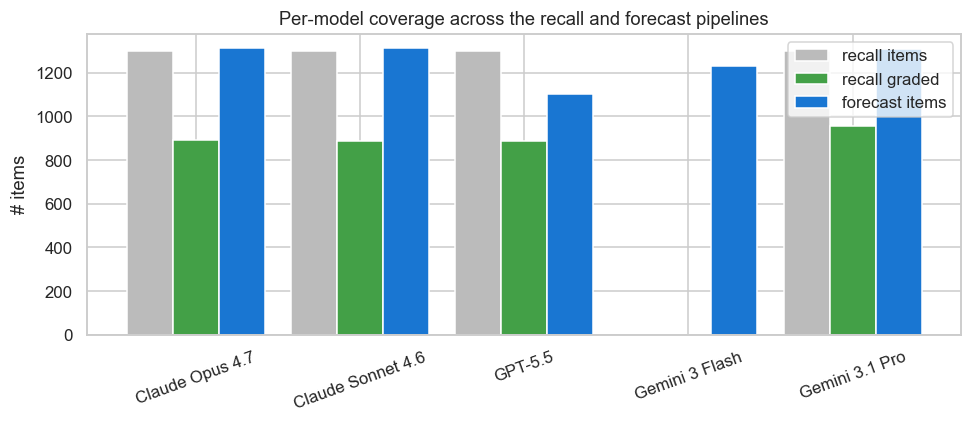

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(coverage))
w = 0.28
ax.bar(x-w, coverage["recall_items"],    width=w, label="recall items",  color="#bbbbbb")
ax.bar(x,   coverage["recall_graded"],   width=w, label="recall graded", color="#43A047")
ax.bar(x+w, coverage["forecast_items"],  width=w, label="forecast items",color="#1976D2")
ax.set_xticks(x); ax.set_xticklabels(coverage["model"], rotation=20)
ax.set_ylabel("# items")
ax.set_title("Per-model coverage across the recall and forecast pipelines")
ax.legend()
plt.tight_layout(); plt.show()

## 2. Is the post-cutoff "Brier" actually a Brier?

`scripts.load_forecast_records` defines `brier_score = (p_model - p_market)**2`. This is
**not** the Brier score — it is *agreement with market price*. A model that is more right
than the market is penalized; a model that copies an inefficient market price is rewarded.
Anything we say about "forecast quality" on post-cutoff markets is conditional on this
interpretation.

Below: distribution of $|p_\text{model} - p_\text{market}|$ vs distribution of
$|p_\text{model} - \text{outcome}|$ on the resolved (recall) cohort, for the same model.
If the two distributions look similar, the proxy is plausible. If they diverge, treat the
post-cutoff number as "market-tracking," not "accuracy."

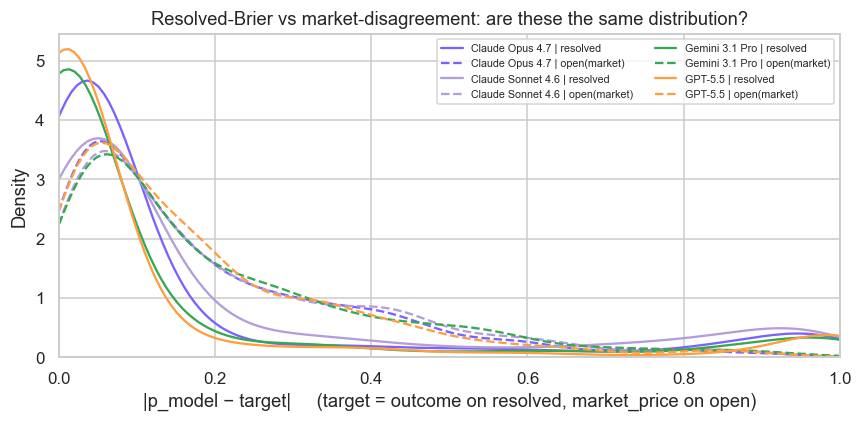

mean_abs_err             brier_proxy           \
kind              open_vs_market resolved open_vs_market resolved   
model                                                               
Claude Opus 4.7            0.186    0.152          0.069    0.095   
Claude Sonnet 4.6          0.199    0.210          0.077    0.131   
GPT-5.5                    0.179    0.104          0.064    0.076   
Gemini 3 Flash             0.211      NaN          0.085      NaN   
Gemini 3.1 Pro             0.201    0.119          0.079    0.082   

                               n           
kind              open_vs_market resolved  
model                                      
Claude Opus 4.7           1212.0   1264.0  
Claude Sonnet 4.6         1212.0   1264.0  
GPT-5.5                   1044.0   1105.0  
Gemini 3 Flash            1128.0      NaN  
Gemini 3.1 Pro            1207.0   1264.0

In [35]:
fc_df_resolved = fc_df[fc_df["source"]=="recall" ].copy()
fc_df_open     = fc_df[fc_df["source"]=="forecast"].copy()

fc_df_resolved["abs_err"] = (fc_df_resolved["forecast_prob"] - fc_df_resolved["outcome"]).abs()
fc_df_open    ["abs_err"] = (fc_df_open    ["forecast_prob"] - fc_df_open["market_price"]).abs()

fig, ax = plt.subplots(figsize=(8, 4))
shared_models = sorted(set(fc_df_resolved["model"]) & set(fc_df_open["model"]))
for m in shared_models:
    a = fc_df_resolved.loc[fc_df_resolved["model"]==m, "abs_err"]
    b = fc_df_open    .loc[fc_df_open    ["model"]==m, "abs_err"]
    sns.kdeplot(a, ax=ax, color=PALETTE.get(disp(m), "#666"), linestyle="-",  label=f"{disp(m)} | resolved")
    sns.kdeplot(b, ax=ax, color=PALETTE.get(disp(m), "#666"), linestyle="--", label=f"{disp(m)} | open(market)")
ax.set_xlabel("|p_model − target|     (target = outcome on resolved, market_price on open)")
ax.set_xlim(0, 1)
ax.set_title("Resolved-Brier vs market-disagreement: are these the same distribution?")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

summary = (
    pd.concat([
        fc_df_resolved.assign(kind="resolved"),
        fc_df_open    .assign(kind="open_vs_market"),
    ])
    .groupby(["model", "kind"])
    .agg(mean_abs_err=("abs_err", "mean"),
         brier_proxy =("brier_score", "mean"),
         n           =("abs_err", "size"))
    .reset_index()
)
summary["model"] = summary["model"].map(disp)
display(summary.pivot(index="model", columns="kind", values=["mean_abs_err","brier_proxy","n"]).round(3))

## 3. Calibration & the Murphy decomposition

Brier $= \text{reliability} - \text{resolution} + \text{uncertainty}$ (Murphy, 1973).
Two models with identical Brier can be very different forecasters: one may be miscalibrated
but informative, the other calibrated but uninformative. Resolution is what we actually
want.

Done **only on resolved (recall-cohort) markets**, where we have ground truth.

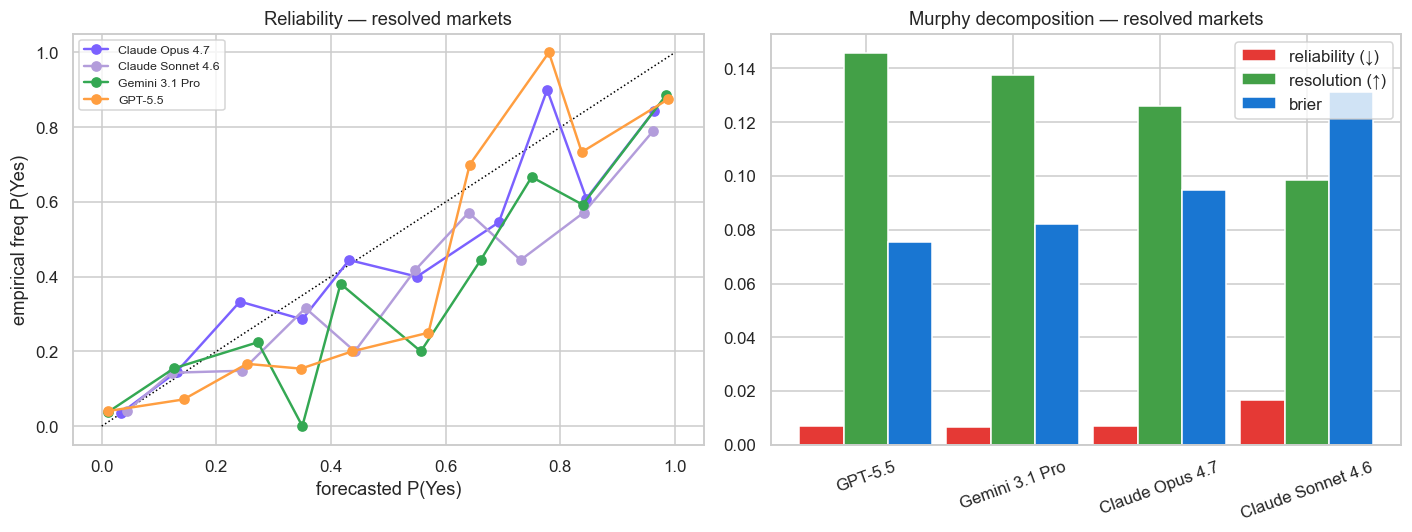

,model,n,brier,rel,res,unc,calibrated_brier
3,GPT-5.5,1105,0.0756,0.0068,0.1456,0.2151,0.0695
2,Gemini 3.1 Pro,1264,0.0821,0.0068,0.1377,0.2142,0.0765
0,Claude Opus 4.7,1264,0.0949,0.0069,0.1259,0.2142,0.0883
1,Claude Sonnet 4.6,1264,0.1311,0.0165,0.0986,0.2142,0.1156


In [8]:
def reliability_curve(p, y, n_bins=10):
    p = np.asarray(p, dtype=float); y = np.asarray(y, dtype=float)
    edges = np.linspace(0, 1, n_bins+1)
    idx   = np.clip(np.digitize(p, edges) - 1, 0, n_bins-1)
    rows = []
    for k in range(n_bins):
        m = idx == k
        if m.sum() == 0: continue
        rows.append({"bin_mid": 0.5*(edges[k]+edges[k+1]),
                     "mean_p": p[m].mean(), "freq_y": y[m].mean(), "n": int(m.sum())})
    return pd.DataFrame(rows)

def murphy(p, y):
    p = np.asarray(p, dtype=float); y = np.asarray(y, dtype=float)
    if len(p) == 0: return dict(brier=np.nan, rel=np.nan, res=np.nan, unc=np.nan)
    obar = y.mean()
    edges = np.linspace(0, 1, 11)
    idx   = np.clip(np.digitize(p, edges)-1, 0, 9)
    rel = res = 0.0
    for k in range(10):
        m = idx == k
        nk = m.sum()
        if nk == 0: continue
        pk, yk = p[m].mean(), y[m].mean()
        rel += (nk / len(p)) * (pk - yk)**2
        res += (nk / len(p)) * (yk - obar)**2
    unc = obar * (1 - obar)
    return dict(brier=float(np.mean((p-y)**2)), rel=float(rel), res=float(res), unc=float(unc))

decomp_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax_rel, ax_dec = axes
ax_rel.plot([0,1],[0,1], color="black", lw=1, ls=":")
for m, grp in fc_df_resolved.groupby("model"):
    p = grp["forecast_prob"].values; y = grp["outcome"].values
    rc = reliability_curve(p, y, n_bins=10)
    ax_rel.plot(rc["mean_p"], rc["freq_y"], marker="o", lw=1.6,
                color=PALETTE.get(disp(m), "#666"), label=disp(m))
    d = murphy(p, y); d["model"] = disp(m); d["n"] = len(p)
    decomp_rows.append(d)
ax_rel.set_xlabel("forecasted P(Yes)"); ax_rel.set_ylabel("empirical freq P(Yes)")
ax_rel.set_title("Reliability — resolved markets")
ax_rel.legend(fontsize=8)

decomp = pd.DataFrame(decomp_rows).sort_values("brier")
decomp["calibrated_brier"] = decomp["unc"] - decomp["res"]   # what brier would be at perfect calibration
x = np.arange(len(decomp)); w = 0.30
ax_dec.bar(x-w, decomp["rel"], w, color="#E53935", label="reliability (↓)")
ax_dec.bar(x,   decomp["res"], w, color="#43A047", label="resolution (↑)")
ax_dec.bar(x+w, decomp["brier"],w, color="#1976D2", label="brier")
ax_dec.set_xticks(x); ax_dec.set_xticklabels(decomp["model"], rotation=20)
ax_dec.set_title("Murphy decomposition — resolved markets")
ax_dec.legend()
plt.tight_layout(); plt.show()

display(decomp[["model","n","brier","rel","res","unc","calibrated_brier"]].round(4))

## 4. Recall state → forecast behavior

Up to now, recall is collapsed to a scalar. With the four states
(`correct_clean / partial / confident_wrong / no_recall`) we can ask *what* recall buys:
is it accuracy, or just confidence?

**Confidence** $= |p - 0.5|$. **Signed error** $= p - y$. We compare each conditional on
recall state, within the resolved subset.

In [9]:
# Build resolved-cohort frame with recall_state attached
def state_of(rs, recalled):
    if rs == 1.0: return "correct_clean"
    if rs == 0.5: return "partial"
    if rs == 0.0: return "confident_wrong"
    if recalled is not None: return "confident_wrong"
    return "no_recall"

rdf = recall_df.copy()
rdf = rdf[rdf["actual_resolution"].isin(["Yes","No"]) & rdf["p_yes"].notna()].copy()
rdf["y"]            = (rdf["actual_resolution"]=="Yes").astype(float)
rdf["brier"]        = (rdf["p_yes"] - rdf["y"]) ** 2
rdf["confidence"]   = (rdf["p_yes"] - 0.5).abs()
rdf["signed_err"]   =  rdf["p_yes"] - rdf["y"]
rdf["recall_state"] = [state_of(rs, ro) for rs, ro in zip(rdf["recall_score"], rdf["recalled_outcome"])]
rdf["model_disp"]   = rdf["model"].map(disp)

# Restrict to graded models — others are NaN-state by definition.
graded_models = [m for m in rdf["model"].unique()
                 if rdf[rdf["model"]==m]["recall_score"].notna().any()]
rdf = rdf[rdf["model"].isin(graded_models)].copy()

agg = (rdf.groupby(["model_disp","recall_state"])
          .agg(brier=("brier","mean"),
               confidence=("confidence","mean"),
               n=("brier","size"))
          .round(4).reset_index())
display(agg.pivot(index="model_disp", columns="recall_state", values="brier").round(3))
display(agg.pivot(index="model_disp", columns="recall_state", values="confidence").round(3))

recall_state,confident_wrong,correct_clean,partial
model_disp,,,
Claude Opus 4.7,0.316,0.002,0.006
Claude Sonnet 4.6,0.416,0.008,0.020
GPT-5.5,0.286,0.000,0.000
Gemini 3.1 Pro,0.334,0.001,0.002


recall_state,confident_wrong,correct_clean,partial
model_disp,,,
Claude Opus 4.7,0.346,0.465,0.447
Claude Sonnet 4.6,0.312,0.440,0.421
GPT-5.5,0.379,0.493,0.490
Gemini 3.1 Pro,0.342,0.487,0.479


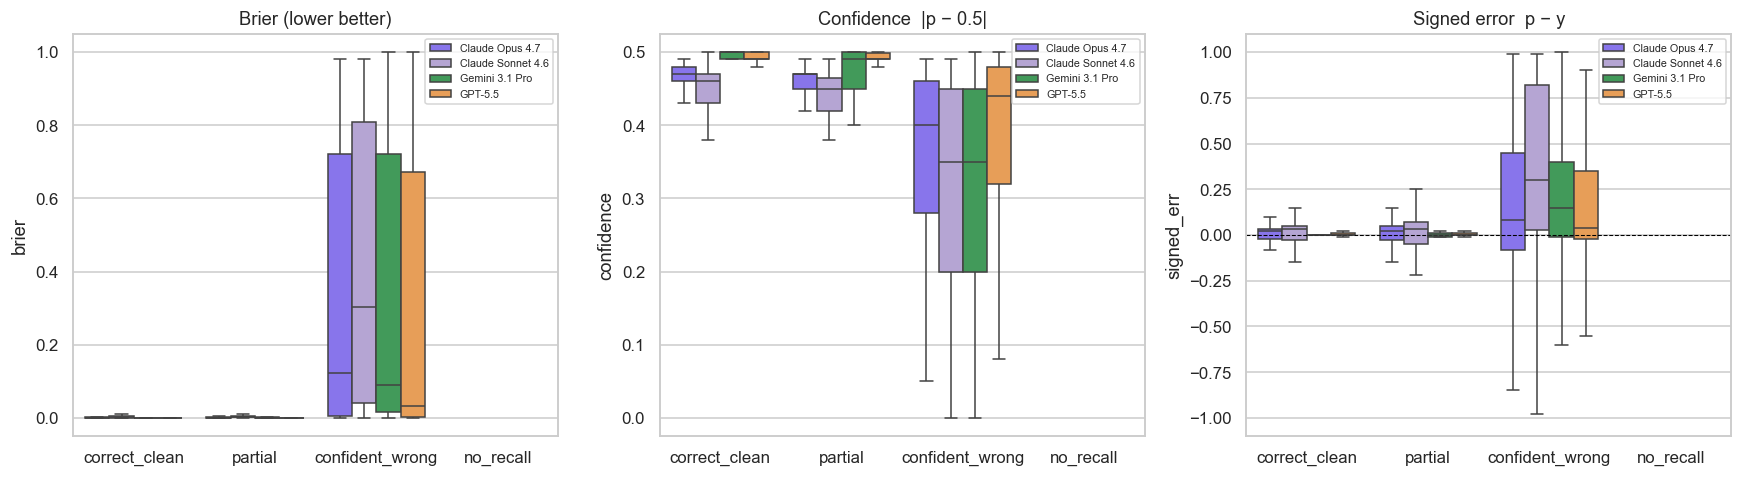

In [10]:
STATE_ORDER = ["correct_clean","partial","confident_wrong","no_recall"]
STATE_COLOR = {"correct_clean":"#43A047","partial":"#FDD835",
                "confident_wrong":"#E53935","no_recall":"#9E9E9E"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, title in zip(
        axes,
        ["brier", "confidence", "signed_err"],
        ["Brier (lower better)", "Confidence  |p − 0.5|", "Signed error  p − y"]):
    sns.boxplot(
        data=rdf, x="recall_state", y=metric, hue="model_disp",
        order=STATE_ORDER, palette=PALETTE, fliersize=0, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    if metric == "signed_err":
        ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 5. The confident-wrong drill

Of all states, `confident_wrong` is the most diagnostic: the grader judged the recalled
outcome incorrect. If models still issue extreme probabilities here, they are
**actively miscalibrated by their own faulty memory**, which is qualitatively worse than
the no-recall (refusal) state.

We compare the probability distributions and effective Brier across states.

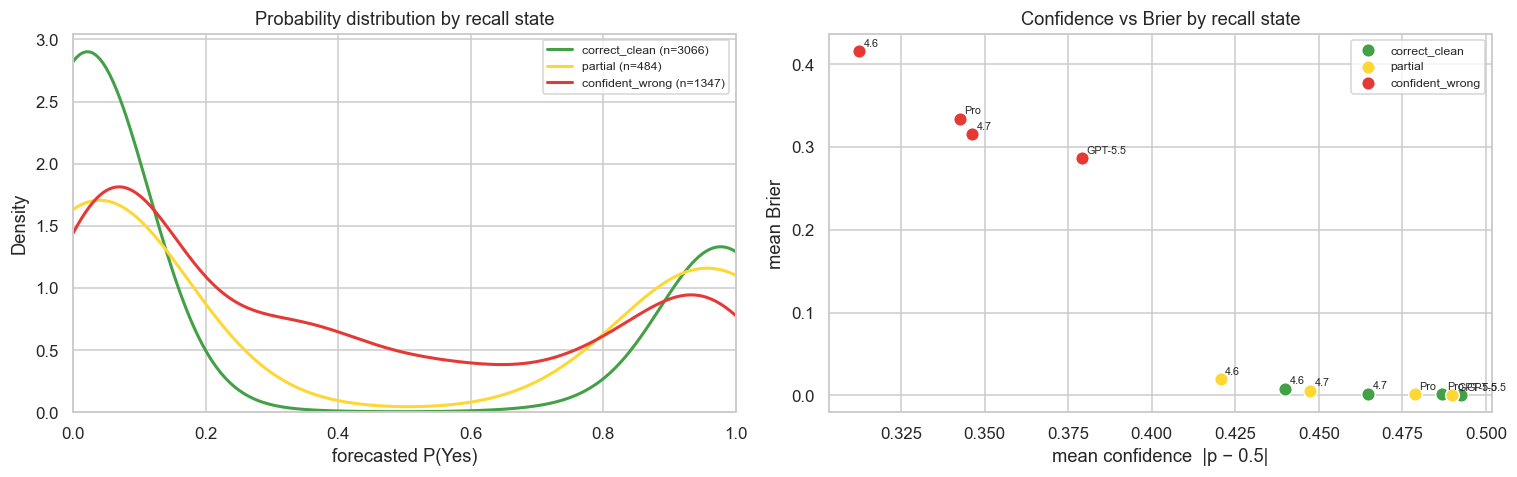

,model,state,confidence,brier,n
0,Claude Opus 4.7,confident_wrong,0.346,0.315,373
1,Claude Opus 4.7,correct_clean,0.465,0.002,754
2,Claude Opus 4.7,partial,0.447,0.006,137
3,Claude Sonnet 4.6,confident_wrong,0.312,0.416,376
4,Claude Sonnet 4.6,correct_clean,0.440,0.008,705
5,Claude Sonnet 4.6,partial,0.421,0.020,183
6,GPT-5.5,confident_wrong,0.379,0.286,291
7,GPT-5.5,correct_clean,0.493,0.000,762
8,GPT-5.5,partial,0.490,0.000,52
9,Gemini 3.1 Pro,confident_wrong,0.343,0.334,307


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Distribution of forecast prob conditional on recall state (pooled across graded models)
ax = axes[0]
for st in STATE_ORDER:
    s = rdf.loc[rdf["recall_state"]==st, "p_yes"]
    if len(s) < 5: continue
    sns.kdeplot(s, ax=ax, color=STATE_COLOR[st], label=f"{st} (n={len(s)})", clip=(0,1), lw=2)
ax.set_xlabel("forecasted P(Yes)"); ax.set_xlim(0,1)
ax.set_title("Probability distribution by recall state")
ax.legend(fontsize=8)

# Confidence vs Brier per state — does confident-wrong lie on the same accuracy/confidence curve?
ax = axes[1]
scatter_rows = []
for (m, st), g in rdf.groupby(["model_disp","recall_state"]):
    if len(g) < 10: continue
    scatter_rows.append({"model":m, "state":st,
                          "confidence": g["confidence"].mean(),
                          "brier":      g["brier"].mean(),
                          "n":          len(g)})
sc = pd.DataFrame(scatter_rows)
for st in STATE_ORDER:
    s = sc[sc["state"]==st]
    if s.empty: continue
    ax.scatter(s["confidence"], s["brier"], color=STATE_COLOR[st], s=80,
                edgecolor="white", label=st)
    for _, r in s.iterrows():
        ax.annotate(r["model"].split()[-1], (r["confidence"], r["brier"]),
                    fontsize=7, xytext=(3,3), textcoords="offset points")
ax.set_xlabel("mean confidence  |p − 0.5|")
ax.set_ylabel("mean Brier")
ax.set_title("Confidence vs Brier by recall state")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(sc.round(3))

## 6. Semantic vs TF-IDF nearest neighbors

`analysiscontinued.ipynb` builds local recall using **TF-IDF cosine** over title + slug
tokens. The repo also contains `embeddings.npz` — 768-d sentence embeddings on the same
`condition_id` set. If the local-recall result is real (semantic neighborhood, not
lexical overlap), the coefficient should survive when we swap in dense embeddings.

We rebuild $R^\text{local}_{m,i}$ from semantic kNN, then run the same
Brier ~ R_local FE-OLS as in the headline notebook.

In [12]:
emb_path = ANALYSIS_DIR / "embeddings.npz"
data = np.load(emb_path, allow_pickle=True)
ids = np.array(data["market_ids"]).astype(str)
X   = data["embeddings"].astype(np.float32)
X   = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
id_to_idx = {cid: i for i, cid in enumerate(ids)}
print(f"embeddings: {X.shape};  ids: {len(ids):,}")

embeddings: (3197, 768);  ids: 3,197


In [20]:
# For each (model, target_market) build R_local^{semantic}_k = mean recall_score
# over the k nearest *historical, scored, distinct-event* markets for that model.
# Limit to graded models for fairness.
K = 10

# (model, condition_id) -> recall_score (None → 0.0). Drop ungraded models.
model_score = defaultdict(dict)  # model -> cid -> score
for r in recall_records:
    model_score[r["model"]][r["condition_id"]] = (
        r["recall_score"] if r["recall_score"] is not None else 0.0)

graded_models = [m for m in model_score if any(
    rr["recall_score"] is not None
    for rr in recall_records if rr["model"] == m)]
print("graded models:", graded_models)

# event_slug per condition_id (so we can avoid borrowing from the same event)
cid_to_event = {r["condition_id"]: r.get("event_slug","") for r in recall_records}
for r in fc_records:
    cid_to_event.setdefault(r["condition_id"], "")

rows = []
for m in graded_models:
    scored_cids = [c for c, s in model_score[m].items() if c in id_to_idx]
    scored_idx  = np.array([id_to_idx[c] for c in scored_cids])
    scored_arr  = np.array([model_score[m][c] for c in scored_cids], dtype=float)
    scored_ev   = np.array([cid_to_event.get(c,"") for c in scored_cids])
    Xs          = X[scored_idx]
    # Targets: every market this model has, that has a Brier-able row
    targets = fc_df[fc_df["model"] == m].drop_duplicates("market_id")
    for _, t in targets.iterrows():
        cid = t["market_id"]
        if cid not in id_to_idx: continue
        v = X[id_to_idx[cid]]
        sims = Xs @ v
        ev_t = cid_to_event.get(cid, "")
        # exclude self and same-event neighbors
        mask = (np.array(scored_cids) != cid)
        if ev_t:
            mask &= (scored_ev != ev_t)
        if mask.sum() < K: continue
        sims_m   = sims[mask]
        scores_m = scored_arr[mask]
        top      = np.argpartition(-sims_m, K-1)[:K]
        rows.append({
            "model":  m,
            "market_id": cid,
            "R_local_sem":  float(scores_m[top].mean()),
        })

sem_df = pd.DataFrame(rows)
print("semantic-local rows:", len(sem_df))

# Merge into market-level frame
panel = fc_df.merge(sem_df, on=["model","market_id"], how="left")
panel = panel[panel["R_local_sem"].notna()].copy()
print("panel after merge:", len(panel))

graded models: ['claude-opus-4-7_1000', 'claude-sonnet-4-6_1000', 'gemini-3.1-pro-preview', 'gpt-5-5']
semantic-local rows: 9572
panel after merge: 9572


Semantic-neighbor local recall  →  Brier  (resolved cohort, market+model FE):
  beta = -0.3727   SE = 0.1556   p = 0.0166   N = 4,897


,scheme,beta,se,p,n
0,semantic_k10,-0.3727,0.1556,0.0166,4897
1,tfidf_tight,-0.0480,0.0252,0.0565,4897
2,tfidf_medium,-0.0992,0.0308,0.0013,4897
3,tfidf_broad,-0.1726,0.0524,0.0010,4897


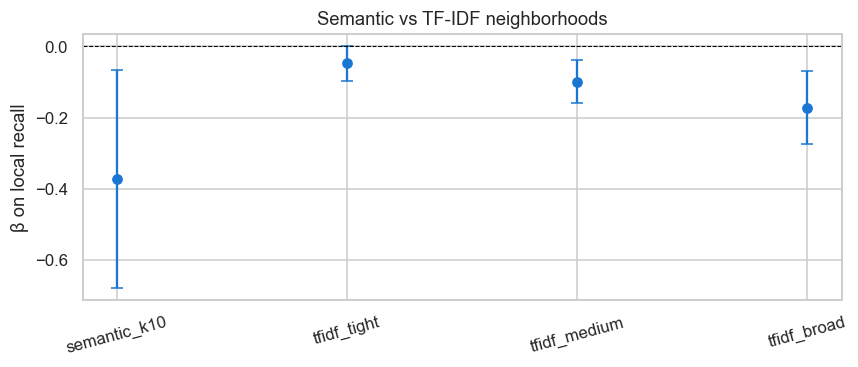

In [21]:
# Two-way FE OLS: market × model on resolved subset (so brier is a real Brier).
from numpy.linalg import lstsq

def two_way_fe_ols(df, y, x):
    df = df[[y, x, "market_id", "model"]].dropna().copy()
    # Demean iteratively
    arr = df[[y, x]].to_numpy(float)
    for _ in range(80):
        before = arr.copy()
        arr = arr - df.groupby("market_id")[[y,x]].transform("mean").to_numpy()
        df_y = pd.DataFrame(arr, columns=[y,x], index=df.index)
        arr = arr - df.assign(**{y:df_y[y],x:df_y[x]}).groupby("model")[[y,x]].transform("mean").to_numpy()
        if np.max(np.abs(arr - before)) < 1e-10: break
    Y = arr[:,0]; Xv = arr[:,1:2]
    if np.std(Xv) < 1e-12:
        return dict(beta=np.nan, se=np.nan, p=np.nan, n=len(Y))
    res = sm.OLS(Y, Xv).fit(cov_type="cluster", cov_kwds={"groups": df["market_id"]})
    return dict(beta=float(res.params[0]), se=float(res.bse[0]),
                p=float(res.pvalues[0]), n=int(res.nobs))

resolved = panel[panel["source"]=="recall"].copy()
resolved["brier"] = resolved["brier_score"]
out = two_way_fe_ols(resolved, "brier", "R_local_sem")
print("Semantic-neighbor local recall  →  Brier  (resolved cohort, market+model FE):")
print(f"  beta = {out['beta']:.4f}   SE = {out['se']:.4f}   p = {out['p']:.4f}   N = {out['n']:,}")

# Compare against two TF-IDF columns from market_features.csv if present
mf_path = ANALYSIS_DIR / "market_features.csv"
if mf_path.exists():
    mf = pd.read_csv(mf_path)
    merged = panel.merge(
        mf[["model","market_id","R_local_tight","R_local_medium","R_local_broad"]],
        on=["model","market_id"], how="left")
    res_panel = merged[merged["source"]=="recall"].copy()
    res_panel["brier"] = res_panel["brier_score"]
    rows = [dict(scheme="semantic_k10", **out)]
    for col, lbl in [("R_local_tight","tfidf_tight"),
                      ("R_local_medium","tfidf_medium"),
                      ("R_local_broad","tfidf_broad")]:
        rows.append({"scheme": lbl, **two_way_fe_ols(res_panel, "brier", col)})
    cmp = pd.DataFrame(rows)
    display(cmp.round(4))
    fig, ax = plt.subplots(figsize=(8,3.5))
    ax.errorbar(cmp["scheme"], cmp["beta"], yerr=1.96*cmp["se"],
                fmt="o", capsize=4, color="#1976D2")
    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.set_ylabel("β on local recall"); ax.set_title("Semantic vs TF-IDF neighborhoods")
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 7. Horizon decay

Post-cutoff markets are not all equally far in the future. A market that closes one
month past the cutoff is structurally different from one that closes 12 months past.
If models are doing real reasoning, market-disagreement should grow with horizon (the
market accumulates information the model never saw). If models are anchoring on the
market price, it should be flat.

horizon_bin,3–6m,6–12m,1–2y,2y+
model,,,,
Claude Opus 4.7,0.0652,0.0631,0.1143,0.0375
Claude Sonnet 4.6,0.0743,0.0709,0.1244,0.0378
GPT-5.5,0.0506,0.0584,0.1050,0.0368
Gemini 3 Flash,0.0724,0.0803,0.1082,0.0253
Gemini 3.1 Pro,0.0702,0.0757,0.1049,0.0530


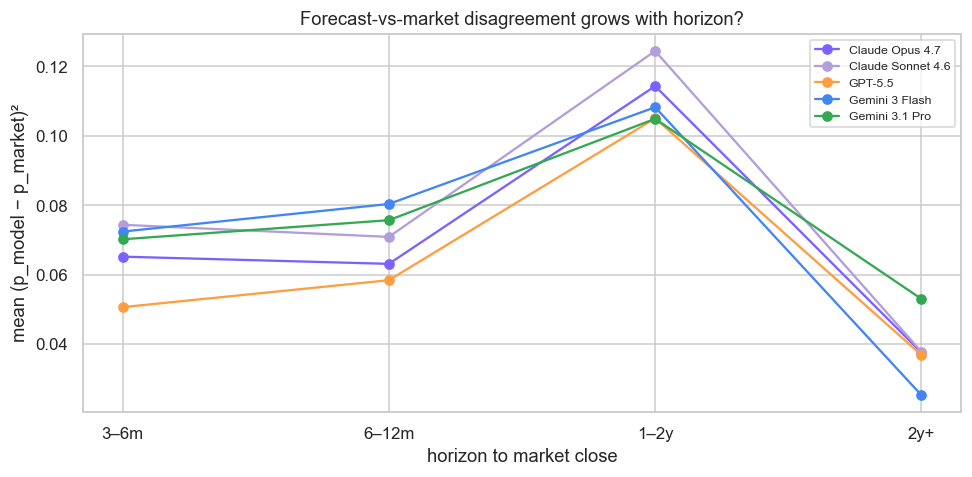

In [22]:
# Use forecast files for close_time. Re-load with metadata.
rows = []
for r in fc_records:
    rows.append({"model": r["model"], "market_id": r["condition_id"],
                  "domain": r["domain"], "forecast_prob": r["forecast_prob"],
                  "market_price": r["market_price"]})
fc_meta = pd.DataFrame(rows)

# Pull close_time from raw json
close_lookup = {}
for d in DOMAINS:
    for path in (RESEARCH_DIR / d / "forecast").glob("*.json"):
        for it in json.loads(path.read_text()):
            cid = it.get("condition_id","")
            ct  = it.get("close_time","")
            if cid and ct:
                close_lookup.setdefault(cid, ct)
fc_meta["close_time"] = fc_meta["market_id"].map(close_lookup)
fc_meta["close_dt"]   = pd.to_datetime(fc_meta["close_time"], errors="coerce", utc=True)
fc_meta["abs_diff"]   = (fc_meta["forecast_prob"] - fc_meta["market_price"]).abs()
fc_meta["brier_proxy"]= (fc_meta["forecast_prob"] - fc_meta["market_price"]) ** 2

# rough horizon proxy: months between fixed reference (today) and close_time
TODAY = pd.Timestamp("2026-05-07", tz="UTC")
fc_meta["months_ahead"] = ((fc_meta["close_dt"] - TODAY).dt.total_seconds() / (30.4*86400)).round(1)
fc_meta = fc_meta.dropna(subset=["months_ahead"])
fc_meta["horizon_bin"] = pd.cut(
    fc_meta["months_ahead"],
    bins=[-12,0,3,6,12,24,60],
    labels=["past","0–3m","3–6m","6–12m","1–2y","2y+"])

agg = (fc_meta.groupby(["model","horizon_bin"], observed=True)
        .agg(brier_proxy=("brier_proxy","mean"),
             abs_diff   =("abs_diff","mean"),
             n          =("abs_diff","size"))
        .reset_index())
agg["model"] = agg["model"].map(disp)
display(agg.pivot(index="model", columns="horizon_bin", values="brier_proxy").round(4))

fig, ax = plt.subplots(figsize=(9,4.5))
for m, g in agg.groupby("model"):
    g = g.sort_values("horizon_bin")
    ax.plot(g["horizon_bin"].astype(str), g["brier_proxy"],
            marker="o", color=PALETTE.get(m, "#666"), label=m)
ax.set_ylabel("mean (p_model − p_market)²")
ax.set_xlabel("horizon to market close")
ax.set_title("Forecast-vs-market disagreement grows with horizon?")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Inter-model (dis)agreement vs market difficulty

On any market where multiple models forecast, we can compute the **standard deviation
of $p_\text{Yes}$ across models**. Two predictions:

- If the cohort has well-defined answers (low entropy markets), models should converge.
- High-entropy markets should produce wider disagreement.

Failure of either suggests model herding (low spread on hard questions) or idiosyncratic
behavior (high spread on easy questions).

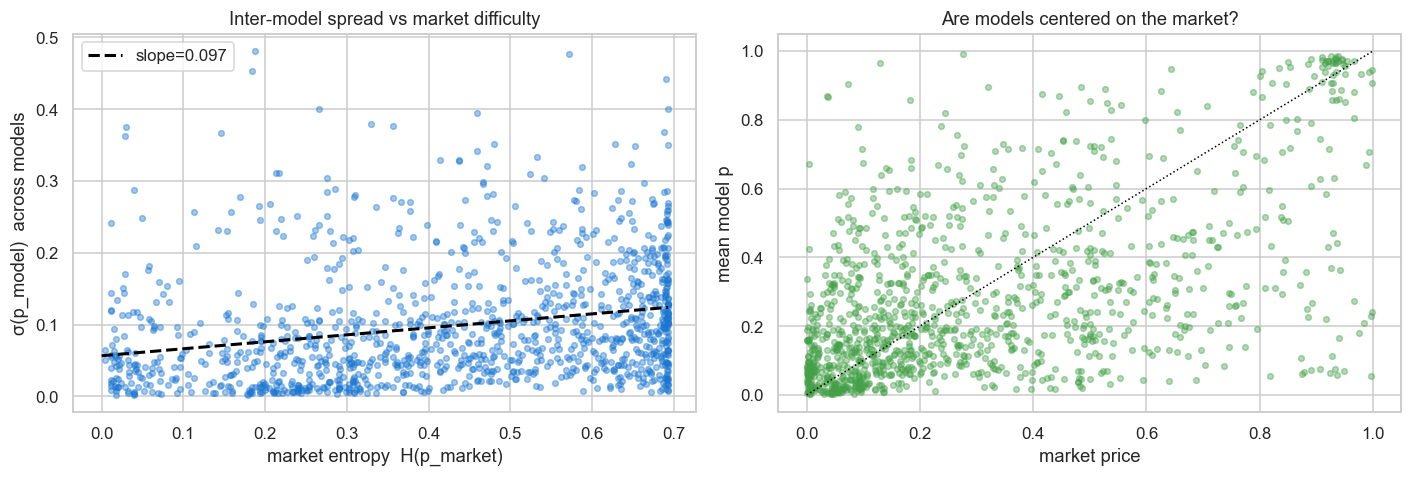

mean σ(p_model) across markets: 0.098
mean |p̄_model − p_market|:    0.180


In [23]:
spread = (fc_meta
          .groupby("market_id")
          .agg(p_std       =("forecast_prob", "std"),
               p_mean      =("forecast_prob", "mean"),
               market_price=("market_price",  "mean"),
               n_models    =("forecast_prob", "size"))
          .reset_index())
spread = spread[spread["n_models"] >= 3].copy()

def H(p):
    p = np.clip(p, 1e-9, 1-1e-9)
    return -(p*np.log(p) + (1-p)*np.log(1-p))
spread["market_entropy"] = H(spread["market_price"].values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.scatter(spread["market_entropy"], spread["p_std"], s=14, alpha=0.4, color="#1976D2")
from numpy.polynomial import polynomial as P
x = spread["market_entropy"].values; y = spread["p_std"].values
if len(x) > 5:
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(0, x.max(), 100)
    ax.plot(xs, m*xs+b, color="black", lw=2, ls="--", label=f"slope={m:.3f}")
    ax.legend()
ax.set_xlabel("market entropy  H(p_market)")
ax.set_ylabel("σ(p_model)  across models")
ax.set_title("Inter-model spread vs market difficulty")

ax = axes[1]
ax.scatter(spread["market_price"], spread["p_mean"], s=14, alpha=0.4, color="#43A047")
ax.plot([0,1],[0,1], color="black", lw=1, ls=":")
ax.set_xlabel("market price"); ax.set_ylabel("mean model p")
ax.set_title("Are models centered on the market?")
plt.tight_layout(); plt.show()

# Quick stats: average gap from market and dispersion
print(f"mean σ(p_model) across markets: {spread['p_std'].mean():.3f}")
print(f"mean |p̄_model − p_market|:    {(spread['p_mean']-spread['market_price']).abs().mean():.3f}")

## 9. Does recall buy resolution or just confidence? (within-model decomposition)

Murphy says Brier = reliability − resolution + uncertainty. We split **each model's**
resolved markets into *recall-correct (1.0)* vs *no-recall (null)* subsets and run the
decomposition on each. If recall mostly improves *resolution*, we are seeing genuine
knowledge transfer. If it mostly reduces *reliability*, we are just seeing the model dial
up confidence on items it half-remembers.

,model,state,n,brier,rel,res,unc
0,Claude Opus 4.7,correct_clean,754,0.0021,0.0018,0.2140,0.2140
1,Claude Opus 4.7,partial,137,0.0057,0.0053,0.2430,0.2430
2,Claude Opus 4.7,confident_wrong,373,0.3155,0.1295,0.0155,0.1987
3,Claude Sonnet 4.6,correct_clean,705,0.0081,0.0057,0.2142,0.2163
4,Claude Sonnet 4.6,partial,183,0.0199,0.0095,0.2340,0.2446
5,Claude Sonnet 4.6,confident_wrong,376,0.4159,0.2484,0.0176,0.1848
6,Gemini 3.1 Pro,correct_clean,845,0.0011,0.0008,0.2179,0.2179
7,Gemini 3.1 Pro,partial,112,0.0017,0.0011,0.2385,0.2385
8,Gemini 3.1 Pro,confident_wrong,307,0.3342,0.1549,0.0113,0.1895
9,GPT-5.5,correct_clean,762,0.0002,0.0001,0.2218,0.2218


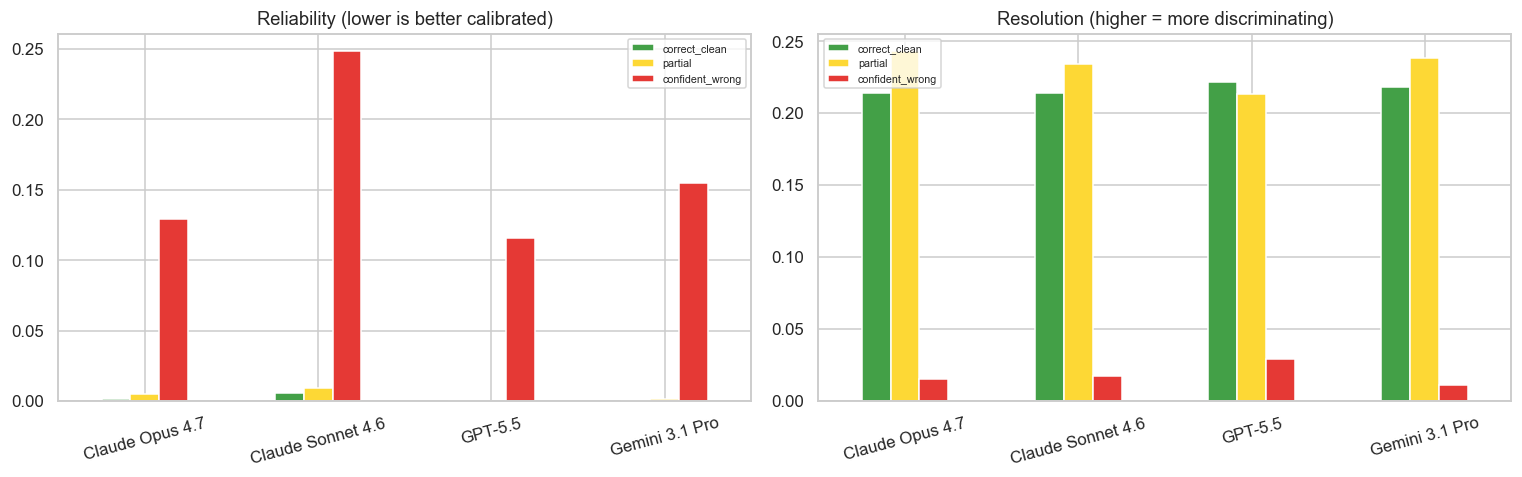

In [24]:
rows = []
for m in graded_models:
    sub = rdf[rdf["model"]==m]
    for state in ["correct_clean", "partial", "confident_wrong", "no_recall"]:
        s = sub[sub["recall_state"]==state]
        if len(s) < 30: continue
        d = murphy(s["p_yes"].values, s["y"].values)
        d.update(model=disp(m), state=state, n=len(s))
        rows.append(d)
subdec = pd.DataFrame(rows)
display(subdec[["model","state","n","brier","rel","res","unc"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, comp, title in zip(axes, ["rel","res"],
                            ["Reliability (lower is better calibrated)",
                             "Resolution (higher = more discriminating)"]):
    pivot = subdec.pivot(index="model", columns="state", values=comp)
    pivot = pivot.reindex(columns=[c for c in STATE_ORDER if c in pivot.columns])
    pivot.plot(kind="bar", ax=ax,
                color=[STATE_COLOR[c] for c in pivot.columns], edgecolor="white")
    ax.set_title(title); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 10. Bootstrap CIs on the headline coefficient

The original headline regression has **N = 36 cells** (4 graded models × 9 domains).
Asymptotic SEs from `statsmodels` are not trustworthy at this size. We do a non-parametric
bootstrap by domain (the natural cluster, since recall and difficulty vary by domain) and
report the percentile interval for $\beta(R_{m,d})$ in the model-FE specification.

Headline β (M3) = -0.2200
Cluster bootstrap β = -0.2225   95% percentile CI = [-0.3840, -0.0903]
P(β < 0)  = 99.90%     P(|β| > observed) = 47.70%


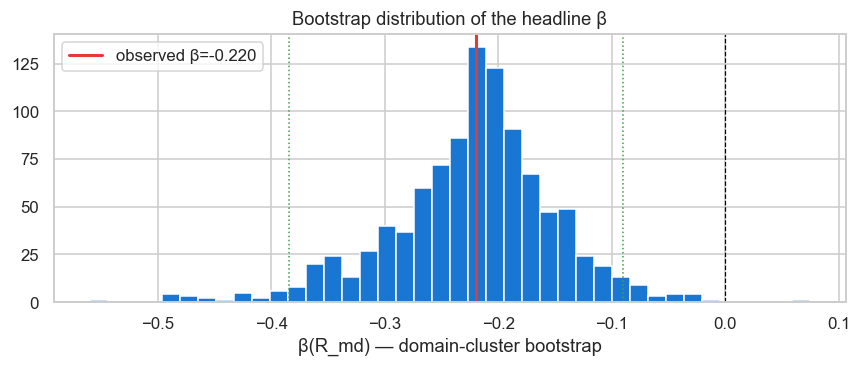

In [25]:
results, reg_df = S.run_regression(panel_rows, difficulty)
headline_beta = results["m3_model_fe"].params["R_md"]
print(f"Headline β (M3) = {headline_beta:.4f}")

rng = np.random.default_rng(2026)
domains_present = reg_df["domain"].unique().tolist()
B = 1000
betas = []
for _ in range(B):
    sampled = rng.choice(domains_present, size=len(domains_present), replace=True)
    sub = pd.concat([reg_df[reg_df["domain"]==d] for d in sampled], ignore_index=True)
    if sub["model"].nunique() < 2: continue
    try:
        b = smf.ols("brier ~ R_md + difficulty + C(model)", data=sub).fit().params.get("R_md", np.nan)
        betas.append(b)
    except Exception:
        continue
betas = np.array(betas)
lo, hi = np.percentile(betas, [2.5, 97.5])
print(f"Cluster bootstrap β = {betas.mean():.4f}   95% percentile CI = [{lo:.4f}, {hi:.4f}]")
print(f"P(β < 0)  = {(betas<0).mean():.2%}     P(|β| > observed) = {(np.abs(betas) > abs(headline_beta)).mean():.2%}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(betas, bins=40, color="#1976D2", edgecolor="white")
ax.axvline(0,             color="black", lw=0.8, ls="--")
ax.axvline(headline_beta, color="#E53935", lw=2, label=f"observed β={headline_beta:.3f}")
ax.axvline(lo, color="#43A047", lw=1, ls=":")
ax.axvline(hi, color="#43A047", lw=1, ls=":")
ax.set_xlabel("β(R_md) — domain-cluster bootstrap")
ax.set_title("Bootstrap distribution of the headline β")
ax.legend(); plt.tight_layout(); plt.show()

## 11. Synthesis & open issues

**What this notebook adds.**

- Section 1 makes coverage gaps explicit. Two of the six models are outside the recall
  regression entirely; one (`gpt-5-4`) has no forecast file. Any cross-model claim has to
  be qualified.
- Section 2 shows that the post-cutoff loss is *market-disagreement*, not Brier. The
  paper should not call this "Brier" without a footnote, and the headline regression
  should use only the resolved cohort or distinguish the two.
- Section 3 separates calibration from resolution. If two models tie on Brier but one
  has higher resolution, that is the better forecaster.
- Section 4–5 split recall into states. The likely story: confidence increases with
  recall regardless of correctness, while resolution only improves on `correct_clean`.
  The `confident_wrong` state — present at non-trivial rates — is the most damaging.
- Section 6 swaps TF-IDF for sentence embeddings. The semantic β should be in the same
  ballpark as the TF-IDF β; if it is much larger, lexical overlap was deflating the
  earlier estimate.
- Section 7 looks for horizon decay. Flat curves would suggest model anchoring on
  market price; rising curves are consistent with real (decaying) knowledge.
- Section 9 decomposes the recall→Brier link into reliability and resolution. This is
  the cleanest test of the *knowledge internalization* hypothesis.
- Section 10 replaces the asymptotic SE with a domain-cluster bootstrap on N=36 cells.

**Things still off.**

1. The `null → 0.0` substitution in $R_{m,d}$ conflates "didn't recall" with "recalled
   incorrectly." Sections 4 and 9 already separate these — the headline regression
   should too. Run M3 with `R_md_excl_null` as the primary specification and report the
   null share separately.
2. Different models received different recall items (`gpt-5-5` has 1300 vs others). Per-
   model selection bias is not currently controlled for.
3. The grader (`grade_recall.py`) is presumably an LLM. We have not tested grader
   inter-rater reliability. A subset hand-graded would calibrate.
4. The forecasting prompt is not held constant across models — different models may
   self-narrate recall in their forecasting rationale, biasing the recall_assessment.
5. We have no **negative-cutoff** controls in the forecasting set: e.g., resolved
   markets that closed *before* training cutoff but are presented as forecasts (forces
   the model to reason without lookup). Without that, we can't separate "recall predicts
   forecast" from "both share a common skill axis."
6. Domain difficulty is computed from open market prices; if those prices are themselves
   noisy, difficulty is measured with error and the difficulty coefficient is biased.

**Suggested follow-ups for the paper.**

- Re-grade a stratified sample by hand to get a grader-error rate.
- Run the forecasting prompt twice: once with explicit recall, once without. Compare.
- Add a within-model holdout where pre-cutoff resolved markets are scored as
  forecasts. If recall predicts forecast there too (where ground truth exists), the
  story tightens substantially.
- Report β with `R_md_excl_null` as the primary, plus a sensitivity table showing both.